## Research Agent
#### Langgraph, GPT-4o, RAG, PineCone, ArXiv and Google SerpAPI

### Extracting Data from ArXiv into a Pandas DataFrame and Saving it as JSON

In [1]:
# pip install -r requirements.txt -q

In [2]:
import requests
import pandas as pd
import json
import xml.etree.ElementTree as ET

# Namespace for ArXiv's Atom-based XML format.
ARXIV_NAMESPACE = '{http://www.w3.org/2005/Atom}'

def extract_from_arxiv(search_query='cat:cs.AI', max_results=100, json_file_path='files/arxiv_dataset.json'):
    """
    Fetches papers from the ArXiv API based on a search query, saves them as JSON, 
    and returns a pandas DataFrame.

    Args:
        search_query (str): The search query for ArXiv (default is 'cat:cs.AI').
        max_results (int): The maximum number of results to retrieve (default is 100).
        json_file_path (str): File path where JSON data will be saved.

    Returns:
        pd.DataFrame: DataFrame containing the extracted paper information.
    """
    
    # Construct the URL for the API request.
    url = f'http://export.arxiv.org/api/query?search_query={search_query}&max_results={max_results}'
    
    # Send a GET request to the ArXiv API.
    response = requests.get(url)
    
    # Parse the XML response.
    root = ET.fromstring(response.content)
    
    papers = []
    
    # Loop through each "entry" in the XML, representing a single paper.
    for entry in root.findall(f'{ARXIV_NAMESPACE}entry'):
        title = entry.find(f'{ARXIV_NAMESPACE}title').text.strip()
        summary = entry.find(f'{ARXIV_NAMESPACE}summary').text.strip()

        # Get the authors of the paper.
        author_elements = entry.findall(f'{ARXIV_NAMESPACE}author')
        authors = [author.find(f'{ARXIV_NAMESPACE}name').text for author in author_elements]

        # Get the paper's URL.
        paper_url = entry.find(f'{ARXIV_NAMESPACE}id').text
        arxiv_id = paper_url.split('/')[-1]

        # Check for the PDF link.
        pdf_link = next((link.attrib['href'] for link in entry.findall(f'{ARXIV_NAMESPACE}link') 
                         if link.attrib.get('title') == 'pdf'), None)

        papers.append({
            'title': title,
            'summary': summary,
            'authors': authors,
            'arxiv_id': arxiv_id,
            'url': paper_url,
            'pdf_link': pdf_link
        })
    
    # Convert list into a pandas DataFrame.
    df = pd.DataFrame(papers)
    
    # Save the DataFrame to a JSON file.
    with open(json_file_path, 'w', encoding='utf-8') as f:
        json.dump(papers, f, ensure_ascii=False, indent=4)
        print(f'Data saved to {json_file_path} ...')
    
    return df


In [3]:
df = extract_from_arxiv(max_results=20)

Data saved to files/arxiv_dataset.json ...


In [4]:
import json
file_name = 'files/arxiv_dataset.json'

with open(file_name, 'r') as file:
    data = json.load(file)

print(data)

[{'title': 'A Deep Reinforcement Learning Approach for Ramp Metering Based on Traffic Video Data', 'summary': 'Ramp metering that uses traffic signals to regulate vehicle flows from the on-ramps has been widely implemented to improve vehicle mobility of the freeway. Previous studies generally update signal timings in real-time based on predefined traffic measures collected by point detectors, such as traffic volumes and occupancies. Comparing with point detectors, traffic cameras-which have been increasingly deployed on road networks-could cover larger areas and provide more detailed traffic information. In this work, we propose a deep reinforcement learning (DRL) method to explore the potential of traffic video data in improving the efficiency of ramp metering. The proposed method uses traffic video frames as inputs and learns the optimal control strategies directly from the high-dimensional visual inputs. A real-world case study demonstrates that, in comparison with a state-of-the-pr

In [5]:
df =  pd.DataFrame(data)
df.sample(n=5)

,title,summary,authors,arxiv_id,url,pdf_link
5,Skeleton-based Approaches based on Machine Vis...,"Recently, skeleton-based approaches have achie...","[Jie Li, Binglin Li, Min Gao]",2012.12447v1,http://arxiv.org/abs/2012.12447v1,https://arxiv.org/pdf/2012.12447v1
3,Generalization in portfolio-based algorithm se...,Portfolio-based algorithm selection has seen t...,"[Maria-Florina Balcan, Tuomas Sandholm, Ellen ...",2012.13315v1,http://arxiv.org/abs/2012.13315v1,https://arxiv.org/pdf/2012.13315v1
4,"I like fish, especially dolphins: Addressing C...",To quantify how well natural language understa...,"[Yixin Nie, Mary Williamson, Mohit Bansal, Dou...",2012.13391v2,http://arxiv.org/abs/2012.13391v2,https://arxiv.org/pdf/2012.13391v2
8,Dynamic-K Recommendation with Personalized Dec...,"In this paper, we investigate the recommendati...","[Yan Gao, Jiafeng Guo, Yanyan Lan, Huaming Liao]",2012.13569v1,http://arxiv.org/abs/2012.13569v1,https://arxiv.org/pdf/2012.13569v1
16,Decision Making with Machine Learning and ROC ...,The Receiver Operating Characteristic (ROC) cu...,"[Kai Feng, Han Hong, Ke Tang, Jingyuan Wang]",1905.02810v1,http://arxiv.org/abs/1905.02810v1,https://arxiv.org/pdf/1905.02810v1


### Downloading the Research Papers (PDFs)

In [6]:
import os

def download_pdfs(df, download_folder='files'):
    # Create the folder if does not exist
    if not os.path.exists(download_folder):
        os.makedirs(download_folder)

    pdf_file_names = []

    # Loop through each row fromt he dataframe
    for index, row in df.iterrows():
        pdf_link = row['pdf_link']

        try:
            response = requests.get(pdf_link)
            response.raise_for_status()

            file_name = os.path.join(download_folder, pdf_link.split("/")[-1]) + '.pdf'
            pdf_file_names.append(file_name)

            with open(file_name, 'wb') as file:
                file.write(response.content)

            print(f'PDF downloaded successfully and saved as {file_name}')
        except requests.exceptions.RequestException as e:
            print(f'Failed to download the PDF: {e}')
            pdf_file_names.append(None)
    df['pdf_file_name'] = pdf_file_names

    return df
            

In [7]:
df = download_pdfs(df)

PDF downloaded successfully and saved as files\2012.12104v1.pdf
PDF downloaded successfully and saved as files\2012.13026v1.pdf
PDF downloaded successfully and saved as files\2012.13293v1.pdf
PDF downloaded successfully and saved as files\2012.13315v1.pdf
PDF downloaded successfully and saved as files\2012.13391v2.pdf
PDF downloaded successfully and saved as files\2012.12447v1.pdf
PDF downloaded successfully and saved as files\2012.12634v1.pdf
PDF downloaded successfully and saved as files\2012.11903v1.pdf
PDF downloaded successfully and saved as files\2012.13569v1.pdf
PDF downloaded successfully and saved as files\2012.12718v1.pdf
PDF downloaded successfully and saved as files\2012.13666v1.pdf
PDF downloaded successfully and saved as files\2012.13677v1.pdf
PDF downloaded successfully and saved as files\2012.13779v1.pdf
PDF downloaded successfully and saved as files\2012.14005v1.pdf
PDF downloaded successfully and saved as files\1904.07934v2.pdf
PDF downloaded successfully and saved as

In [8]:
df

,title,summary,authors,arxiv_id,url,pdf_link,pdf_file_name
0,A Deep Reinforcement Learning Approach for Ram...,Ramp metering that uses traffic signals to reg...,"[Bing Liu, Yu Tang, Yuxiong Ji, Yu Shen, Yuchu...",2012.12104v1,http://arxiv.org/abs/2012.12104v1,https://arxiv.org/pdf/2012.12104v1,files\2012.12104v1.pdf
1,Rethink AI-based Power Grid Control: Diving In...,"Recently, deep reinforcement learning (DRL)-ba...","[Xiren Zhou, Siqi Wang, Ruisheng Diao, Desong ...",2012.13026v1,http://arxiv.org/abs/2012.13026v1,https://arxiv.org/pdf/2012.13026v1,files\2012.13026v1.pdf
2,Fuzzy Commitments Offer Insufficient Protectio...,"In this work, we study the protection that fuz...","[Danny Keller, Margarita Osadchy, Orr Dunkelman]",2012.13293v1,http://arxiv.org/abs/2012.13293v1,https://arxiv.org/pdf/2012.13293v1,files\2012.13293v1.pdf
3,Generalization in portfolio-based algorithm se...,Portfolio-based algorithm selection has seen t...,"[Maria-Florina Balcan, Tuomas Sandholm, Ellen ...",2012.13315v1,http://arxiv.org/abs/2012.13315v1,https://arxiv.org/pdf/2012.13315v1,files\2012.13315v1.pdf
4,"I like fish, especially dolphins: Addressing C...",To quantify how well natural language understa...,"[Yixin Nie, Mary Williamson, Mohit Bansal, Dou...",2012.13391v2,http://arxiv.org/abs/2012.13391v2,https://arxiv.org/pdf/2012.13391v2,files\2012.13391v2.pdf
5,Skeleton-based Approaches based on Machine Vis...,"Recently, skeleton-based approaches have achie...","[Jie Li, Binglin Li, Min Gao]",2012.12447v1,http://arxiv.org/abs/2012.12447v1,https://arxiv.org/pdf/2012.12447v1,files\2012.12447v1.pdf
6,Overview of FPGA deep learning acceleration ba...,"In recent years, deep learning has become more...",[Simin Liu],2012.12634v1,http://arxiv.org/abs/2012.12634v1,https://arxiv.org/pdf/2012.12634v1,files\2012.12634v1.pdf
7,Modelling Human Routines: Conceptualising Soci...,Our routines play an important role in a wide ...,"[Rijk Mercuur, Virginia Dignum, Catholijn M. J...",2012.11903v1,http://arxiv.org/abs/2012.11903v1,https://arxiv.org/pdf/2012.11903v1,files\2012.11903v1.pdf
8,Dynamic-K Recommendation with Personalized Dec...,"In this paper, we investigate the recommendati...","[Yan Gao, Jiafeng Guo, Yanyan Lan, Huaming Liao]",2012.13569v1,http://arxiv.org/abs/2012.13569v1,https://arxiv.org/pdf/2012.13569v1,files\2012.13569v1.pdf
9,Compliance Generation for Privacy Documents un...,Most prominent research today addresses compli...,"[David Restrepo Amariles, Aurore ClÃ©ment Trou...",2012.12718v1,http://arxiv.org/abs/2012.12718v1,https://arxiv.org/pdf/2012.12718v1,files\2012.12718v1.pdf


### Loading and Splitting PDF Files into Chunks, Expanding the Dataframe

In [9]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

def load_and_chunk_pdf(pdf_file_name, chunk_size=512):
    """
    Loads a PDF file and chunks the content of the file.

    Args:
        pdf_file_name (str) -> path to the PDf file
        chunk_size (int) -> The maximum size of each chunk in characters (default is 512)

    Returns:
        List[Document]: List of document chunks
    """

    print(f'Loading nd splitting into chunks: {pdf_file_name}')
    
    loader = PyPDFLoader(pdf_file_name)
    data = loader.load()

    text_splitter = RecursiveCharacterTextSplitter(chunk_size=chunk_size, chunk_overlap=64)
    chunks = text_splitter.split_documents(data)
    return chunks

In [10]:
def expand_df(df):
    """
    Expands each row in the Dataframe by splitting PDF documents into chunks.

    Args:
        df (pd.DataFrame): DatFrame

    Returns:
        pd.DataFrame: A new DataFrame where each row represents a chunk of the original document, 
                      with additional metadata such as chunk identifiers and relationships to adjacent chunks.
    """

    expanded_rows = [] # List to store exapnded rows with chunk information

    # Loop through each row in the DataFrame
    for idx, row in df.iterrows():
        try:
            chunks = load_and_chunk_pdf(row['pdf_file_name'])
        except Exception as e:
            print(f"Error processing file {row['pdf_file_name']}: {e}")
            continue

        for i, chunk in enumerate(chunks):
            prechunk_id = i-1 if i > 0 else '' # Preceding chunk ID
            post_chunk_id = i+1 if i < len(chunks) - 1 else '' # Following chunk id

            expanded_rows.append({
                'id': f"{row['arxiv_id']}#{i}", # Unique chunk identifier
                'title': row['title'],
                'summary': row['summary'],
                'authors': row['authors'],
                'arxiv_id': row['arxiv_id'],
                'url': row['url'],
                'chunk': chunk.page_content, # Text content of the chunk
                'prechunk_id': '' if i == 0 else f"{row['arxiv_id']}#{prechunk_id}",
                'postchunk_id': '' if i == len(chunks) else f"{row['arxiv_id']}#{post_chunk_id}"
            })
    return pd.DataFrame(expanded_rows)

In [11]:
expanded_df = expand_df(df)

Loading nd splitting into chunks: files\2012.12104v1.pdf
Loading nd splitting into chunks: files\2012.13026v1.pdf
Loading nd splitting into chunks: files\2012.13293v1.pdf
Loading nd splitting into chunks: files\2012.13315v1.pdf
Loading nd splitting into chunks: files\2012.13391v2.pdf
Loading nd splitting into chunks: files\2012.12447v1.pdf
Loading nd splitting into chunks: files\2012.12634v1.pdf
Loading nd splitting into chunks: files\2012.11903v1.pdf
Loading nd splitting into chunks: files\2012.13569v1.pdf
Loading nd splitting into chunks: files\2012.12718v1.pdf
Loading nd splitting into chunks: files\2012.13666v1.pdf
Loading nd splitting into chunks: files\2012.13677v1.pdf
Loading nd splitting into chunks: files\2012.13779v1.pdf
Loading nd splitting into chunks: files\2012.14005v1.pdf
Loading nd splitting into chunks: files\1904.07934v2.pdf
Loading nd splitting into chunks: files\1904.08010v1.pdf
Loading nd splitting into chunks: files\1905.02810v1.pdf
Loading nd splitting into chunk

In [12]:
expanded_df

,id,title,summary,authors,arxiv_id,url,chunk,prechunk_id,postchunk_id
0,2012.12104v1#0,A Deep Reinforcement Learning Approach for Ram...,Ramp metering that uses traffic signals to reg...,"[Bing Liu, Yu Tang, Yuxiong Ji, Yu Shen, Yuchu...",2012.12104v1,http://arxiv.org/abs/2012.12104v1,1 \nA Deep Reinforcement Learning Approach for...,,2012.12104v1#1
1,2012.12104v1#1,A Deep Reinforcement Learning Approach for Ram...,Ramp metering that uses traffic signals to reg...,"[Bing Liu, Yu Tang, Yuxiong Ji, Yu Shen, Yuchu...",2012.12104v1,http://arxiv.org/abs/2012.12104v1,Abstract \nRamp metering that uses traffic sig...,2012.12104v1#0,2012.12104v1#2
2,2012.12104v1#2,A Deep Reinforcement Learning Approach for Ram...,Ramp metering that uses traffic signals to reg...,"[Bing Liu, Yu Tang, Yuxiong Ji, Yu Shen, Yuchu...",2012.12104v1,http://arxiv.org/abs/2012.12104v1,and provide more detailed traffic information....,2012.12104v1#1,2012.12104v1#3
3,2012.12104v1#3,A Deep Reinforcement Learning Approach for Ram...,Ramp metering that uses traffic signals to reg...,"[Bing Liu, Yu Tang, Yuxiong Ji, Yu Shen, Yuchu...",2012.12104v1,http://arxiv.org/abs/2012.12104v1,method results in 1) lower travel times in the...,2012.12104v1#2,2012.12104v1#4
4,2012.12104v1#4,A Deep Reinforcement Learning Approach for Ram...,Ramp metering that uses traffic signals to reg...,"[Bing Liu, Yu Tang, Yuxiong Ji, Yu Shen, Yuchu...",2012.12104v1,http://arxiv.org/abs/2012.12104v1,2 \nIntroduction \nRamp metering uses traffic ...,2012.12104v1#3,2012.12104v1#5
...,...,...,...,...,...,...,...,...,...
2134,1905.02019v1#27,Conditioning LSTM Decoder and Bi-directional A...,Applying neural-networks on Question Answering...,[Heguang Liu],1905.02019v1,http://arxiv.org/abs/1905.02019v1,Prediction: stephen colbert\nReason and Propos...,1905.02019v1#26,1905.02019v1#28
2135,1905.02019v1#28,Conditioning LSTM Decoder and Bi-directional A...,Applying neural-networks on Question Answering...,[Heguang Liu],1905.02019v1,http://arxiv.org/abs/1905.02019v1,5.2.4 Inaccurate boundary\nContext: The Super ...,1905.02019v1#27,1905.02019v1#29
2136,1905.02019v1#29,Conditioning LSTM Decoder and Bi-directional A...,Applying neural-networks on Question Answering...,[Heguang Liu],1905.02019v1,http://arxiv.org/abs/1905.02019v1,information. We can tokenize ”the most” into [...,1905.02019v1#28,1905.02019v1#30
2137,1905.02019v1#30,Conditioning LSTM Decoder and Bi-directional A...,Applying neural-networks on Question Answering...,[Heguang Liu],1905.02019v1,http://arxiv.org/abs/1905.02019v1,characters format feature 2) introducing part-...,1905.02019v1#29,1905.02019v1#31


### Building a knowledge base for the RAG System Using Embedding

In [13]:
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv(), override=True)

True

In [14]:
import os
from getpass import getpass
from semantic_router.encoders import OpenAIEncoder

# Check if 'OPENAI_API_KEY' is set
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY') or getpass('OpenAI API key: ')

# Initialize the OpenAIEncoder with a specific model
encoder = OpenAIEncoder(name='text-embedding-3-small')

In [15]:
encoder("hello hallo hota salut")

[[0.0136871337890625,
  0.00644683837890625,
  0.01934814453125,
  0.0301666259765625,
  0.0152130126953125,
  0.002063751220703125,
  -0.0031528472900390625,
  0.050933837890625,
  -0.01546478271484375,
  -0.050018310546875,
  0.01287841796875,
  -0.0015058517456054688,
  -0.07098388671875,
  -0.00457000732421875,
  0.0245208740234375,
  0.01287078857421875,
  -0.024017333984375,
  -0.0032444000244140625,
  0.014251708984375,
  0.041534423828125,
  -0.0208892822265625,
  0.033721923828125,
  0.041168212890625,
  0.039276123046875,
  0.0074005126953125,
  -0.0093841552734375,
  -0.0105133056640625,
  -0.01393890380859375,
  0.0289459228515625,
  -0.01556396484375,
  0.034759521484375,
  -0.03277587890625,
  0.02716064453125,
  -0.02923583984375,
  -0.007694244384765625,
  0.04412841796875,
  -0.049346923828125,
  0.04315185546875,
  -0.0268402099609375,
  0.0228271484375,
  -0.0103302001953125,
  0.00020372867584228516,
  -0.001781463623046875,
  -0.0211181640625,
  0.0316162109375,
  

### Creating a Pinecone Index

In [16]:
from pinecone import Pinecone, ServerlessSpec

# Check if 'PINECONE_API_KEY' is set. Prompt if not.
api_key = os.getenv('PINECONE_API_KEY') or getpass('Pinecone API key:')

In [17]:
# Inititialize the Pinecone client
pc = Pinecone()

# Define the serverless specification for Pinecone (AWS region 'us-east-1')
spec = ServerlessSpec(
    cloud="aws",
    region="us-east-1"
)

In [18]:
import time

# Define the name of the index
index_name = 'research-agent'

# Check if the index exsits
# Create if not
if index_name not in pc.list_indexes().names():
    pc.create_index(
        index_name,
        dimension=1536, # Embedding dimension (1536)
        metric='cosine',
        spec=spec # Cloud provider and region specification
    )

    # Wait until the index is fully initialized
    while not pc.describe_index(index_name).status['ready']:
        time.sleep(1)

# Connect to the index
index = pc.Index(index_name)
time.sleep(1)

# View the index statistics
index.describe_index_stats()

{'_response_info': {'raw_headers': {'connection': 'keep-alive',
                                    'content-length': '151',
                                    'content-type': 'application/json',
                                    'date': 'Sun, 05 Apr 2026 15:35:04 GMT',
                                    'grpc-status': '0',
                                    'server': 'envoy',
                                    'x-envoy-upstream-service-time': '34',
                                    'x-pinecone-request-latency-ms': '33',
                                    'x-pinecone-response-duration-ms': '35'}},
 'dimension': 1536,
 'index_fullness': 0.0,
 'memoryFullness': 0.0,
 'metric': 'cosine',
 'namespaces': {},
 'storageFullness': 0.0,
 'total_vector_count': 0,
 'vector_type': 'dense'}

### Populating the knowledge base and Uploading it to Pinecone

In [19]:
expanded_df.iloc[:5]

,id,title,summary,authors,arxiv_id,url,chunk,prechunk_id,postchunk_id
0,2012.12104v1#0,A Deep Reinforcement Learning Approach for Ram...,Ramp metering that uses traffic signals to reg...,"[Bing Liu, Yu Tang, Yuxiong Ji, Yu Shen, Yuchu...",2012.12104v1,http://arxiv.org/abs/2012.12104v1,1 \nA Deep Reinforcement Learning Approach for...,,2012.12104v1#1
1,2012.12104v1#1,A Deep Reinforcement Learning Approach for Ram...,Ramp metering that uses traffic signals to reg...,"[Bing Liu, Yu Tang, Yuxiong Ji, Yu Shen, Yuchu...",2012.12104v1,http://arxiv.org/abs/2012.12104v1,Abstract \nRamp metering that uses traffic sig...,2012.12104v1#0,2012.12104v1#2
2,2012.12104v1#2,A Deep Reinforcement Learning Approach for Ram...,Ramp metering that uses traffic signals to reg...,"[Bing Liu, Yu Tang, Yuxiong Ji, Yu Shen, Yuchu...",2012.12104v1,http://arxiv.org/abs/2012.12104v1,and provide more detailed traffic information....,2012.12104v1#1,2012.12104v1#3
3,2012.12104v1#3,A Deep Reinforcement Learning Approach for Ram...,Ramp metering that uses traffic signals to reg...,"[Bing Liu, Yu Tang, Yuxiong Ji, Yu Shen, Yuchu...",2012.12104v1,http://arxiv.org/abs/2012.12104v1,method results in 1) lower travel times in the...,2012.12104v1#2,2012.12104v1#4
4,2012.12104v1#4,A Deep Reinforcement Learning Approach for Ram...,Ramp metering that uses traffic signals to reg...,"[Bing Liu, Yu Tang, Yuxiong Ji, Yu Shen, Yuchu...",2012.12104v1,http://arxiv.org/abs/2012.12104v1,2 \nIntroduction \nRamp metering uses traffic ...,2012.12104v1#3,2012.12104v1#5


In [20]:
# For progress bar
from tqdm.auto import tqdm

data = expanded_df
batch_size = 64 # Set the batch size

# Loop through the data in batches, using tqdm for a progress bar
for i in tqdm(range(0, len(data), batch_size)):
    i_end = min(len(data), i + batch_size)  # Define batch endpoint
    batch = data[i:i_end].to_dict(orient='records')  # Slice data into a batch

    # Extract metadata for each chunk in the batch
    metadata = [{
        'arxiv_id': r['arxiv_id'],
        'title': r['title'],
        'chunk': r['chunk'],
    } for r in batch]
    
    # Generate unique IDs for each chunk
    ids = [r['id'] for r in batch]
    
    # Extract the chunk content
    chunks = [r['chunk'] for r in batch]
    
    # Convert chunks into embeddings
    embeds = encoder(chunks)
    
    # Upload embeddings, IDs, and metadata to Pinecone
    index.upsert(vectors=zip(ids, embeds, metadata))


  0%|          | 0/34 [00:00<?, ?it/s]

In [21]:
index.describe_index_stats()

{'_response_info': {'raw_headers': {'connection': 'keep-alive',
                                    'content-length': '188',
                                    'content-type': 'application/json',
                                    'date': 'Sun, 05 Apr 2026 15:36:12 GMT',
                                    'grpc-status': '0',
                                    'server': 'envoy',
                                    'x-envoy-upstream-service-time': '40',
                                    'x-pinecone-request-latency-ms': '39',
                                    'x-pinecone-response-duration-ms': '47'}},
 'dimension': 1536,
 'index_fullness': 0.0,
 'memoryFullness': 0.0,
 'metric': 'cosine',
 'namespaces': {'__default__': {'vector_count': 2139}},
 'storageFullness': 0.0,
 'total_vector_count': 2139,
 'vector_type': 'dense'}

### Implementing the ArXiv Fetch Tool

In [22]:
import requests

In [23]:
# Specify the Arxiv Id
arxiv_id = '1706.03762'

# Make a Get request to retrieve the page for the specified paper
res = requests.get(f'https://arxiv.org/abs/{arxiv_id}')

res.text

'<!DOCTYPE html>\n<html lang="en">\n\n<head>  <title>[1706.03762] Attention Is All You Need</title>\n  <meta name="viewport" content="width=device-width, initial-scale=1">\n  <link rel="apple-touch-icon" sizes="180x180" href="/static/browse/0.3.4/images/icons/apple-touch-icon.png">\n  <link rel="icon" type="image/png" sizes="32x32" href="/static/browse/0.3.4/images/icons/favicon-32x32.png">\n  <link rel="icon" type="image/png" sizes="16x16" href="/static/browse/0.3.4/images/icons/favicon-16x16.png">\n  <link rel="manifest" href="/static/browse/0.3.4/images/icons/site.webmanifest">\n  <link rel="mask-icon" href="/static/browse/0.3.4/images/icons/safari-pinned-tab.svg" color="#5bbad5">\n  <meta name="msapplication-TileColor" content="#da532c">\n  <meta name="theme-color" content="#ffffff">\n  <link rel="stylesheet" type="text/css" media="screen" href="/static/browse/0.3.4/css/arXiv.css?v=20260318" />\n  <link rel="stylesheet" type="text/css" media="print" href="/static/browse/0.3.4/css/a

In [24]:
# Use regular expression to extract the abstract
import re

# Compile a regular expression pattern to find the abstract in the HTML response
abstract_pattern = re.compile(
    r'<blockquote class="abstract mathjax">\s*<span class="descriptor">Abstract:</span>\s*(.*?)\s*</blockquote>',
    re.DOTALL
)

re_match = abstract_pattern.search(res.text)

if re_match:
    print(re_match.group(1))
else:
    print('Abstract not found')
    



The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions entirely. Experiments on two machine translation tasks show these models to be superior in quality while being more parallelizable and requiring significantly less time to train. Our model achieves 28.4 BLEU on the WMT 2014 English-to-German translation task, improving over the existing best results, including ensembles by over 2 BLEU. On the WMT 2014 English-to-French translation task, our model establishes a new single-model state-of-the-art BLEU score of 41.8 after training for 3.5 days on eight GPUs, a small fraction of the training costs of the best models from the literature. We show that the Transforme

In [25]:
from langchain_core.tools import tool
import requests
import re

abstract_pattern = re.compile(
    r'<blockquote class="abstract mathjax">\s*<span class="descriptor">Abstract:</span>\s*(.*?)\s*</blockquote>',
    re.DOTALL
)

@tool('fetch_arxiv')
def fetch_arxiv(arxiv_id: str) -> str:
    """
    Fetches the abstract from an Arxiv paper given its ArXiv ID.

    Args:
        arxiv_id (str): The ArXiv paper ID

    Returns:
        str: The extracted abstract text from the ArXiv paper
    """
    res = requests.get(f'https://arxiv.org/abs/{arxiv_id}')
    re_match = abstract_pattern.search(res.text)
    if re_match:
        return (re_match.group(1))
    else:
        return ('Abstract not found')
    

In [26]:
arxiv_id = '1706.03762'
output = fetch_arxiv.invoke(arxiv_id)
print(output)

The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions entirely. Experiments on two machine translation tasks show these models to be superior in quality while being more parallelizable and requiring significantly less time to train. Our model achieves 28.4 BLEU on the WMT 2014 English-to-German translation task, improving over the existing best results, including ensembles by over 2 BLEU. On the WMT 2014 English-to-French translation task, our model establishes a new single-model state-of-the-art BLEU score of 41.8 after training for 3.5 days on eight GPUs, a small fraction of the training costs of the best models from the literature. We show that the Transforme

### Implementing the Google Serp API Tools

In [27]:
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv(), override=True)

True

In [28]:
from serpapi import GoogleSearch
import os
from getpass import getpass

# Setup the SerpAPI requets paramters, including the API key
serpapi_params= {
    'engine': 'google',
    'api_key': os.getenv('SERPAPI_KEY') or getpass('SerpAPI key: ') # Get the API key
}

# Perform a Goofle search for the keyword "water" and limit the reults to 5
search = GoogleSearch({
    **serpapi_params,
    'q': 'water',
    'num': 5
})

#Extract the main search results from the API response
results = search.get_dict().get('organic_results', [])

# Format the search results for readability.
formatted_results = '\n---\n'.join(
    ['\n'.join([x['title'], x['snippet'], x['link']]) for x in results]
)

In [29]:
print(formatted_results)

Water
Water is an inorganic compound with the chemical formula H 2 O. It is a transparent, tasteless, odorless, [c] and nearly colorless chemical substance
https://en.wikipedia.org/wiki/Water
---
Water | H2O | CID 962 - PubChem - NIH
Water appears as a clear, nontoxic liquid composed of hydrogen and oxygen, essential for life and the most widely used solvent.
https://pubchem.ncbi.nlm.nih.gov/compound/Water
---
Water | Rock Island, IL - Official Website
Rock Island's source of water is the Mississippi River. An average of 5 million gallons are pumped daily to the Water Treatment Plant at 2215 16th Avenue for ...
https://www.rigov.org/866/Water
---
Coordinating the UN's work on water and sanitation
The first-ever UN System-wide Strategy for Water and Sanitation unites UN support to countries to accelerate progress on water-related goals and targets.
https://www.unwater.org/
---
Water | An Open Access Journal from MDPI
Water is a peer-reviewed, open access journal on water science and tec

In [30]:
from serpapi import GoogleSearch

@tool('web_search')
def web_search(query: str) -> str:
    '''
    Finds general knowledge information using a Google search

    Args:
        query (str): The search query string

    Return:
        str: A formatted string of the top search results, including title, snippet, and link.
    '''

    search = GoogleSearch({
        **serpapi_params,
        'q': 'water',
        'num': 5
    })
    
    #Extract the main search results from the API response
    results = search.get_dict().get('organic_results', [])
    
    # Format the search results for readability.
    formatted_results = '\n---\n'.join(
        ['\n'.join([x['title'], x['snippet'], x['link']]) for x in results]
    )
    return formatted_results if results else 'No results found'
    

In [31]:
output = web_search.invoke(input={'query': 'water on mars'})
print(output)

Water
Water is an inorganic compound with the chemical formula H 2 O. It is a transparent, tasteless, odorless, [c] and nearly colorless chemical substance
https://en.wikipedia.org/wiki/Water
---
Water | H2O | CID 962 - PubChem - NIH
Water appears as a clear, nontoxic liquid composed of hydrogen and oxygen, essential for life and the most widely used solvent.
https://pubchem.ncbi.nlm.nih.gov/compound/Water
---
Water | Rock Island, IL - Official Website
Rock Island's source of water is the Mississippi River. An average of 5 million gallons are pumped daily to the Water Treatment Plant at 2215 16th Avenue for ...
https://www.rigov.org/866/Water
---
Coordinating the UN's work on water and sanitation
The first-ever UN System-wide Strategy for Water and Sanitation unites UN support to countries to accelerate progress on water-related goals and targets.
https://www.unwater.org/
---
Water | An Open Access Journal from MDPI
Water is a peer-reviewed, open access journal on water science and tec

### Creating a RAG Tools for Retrieval-Augmented Generation (RAG)

In [32]:
# Helper function to format the retrieved matched documents into human readable format
def format_rag_contexts(matches: list) -> str:
    '''
    Formats the retrieved context matches into a readable string format.
    Args:
        matches (list): A list of matched documents with metadata

    Returns:
        str: A formatted string of dcument titles, chunks and ArXiv IDs.
    '''
    formatted_results = []

    # Loop through each match and extract its metadata
    for x in matches:
        text = (
            f"Title: {x['metadata']['title']}\n"
            f"Chunk: {x['metadata']['chunk']}\n"
            f"ArXiv ID: {x['metadata']['arxiv_id']}\n"
        )
        formatted_results.append(text)

    return '\n---\n'.join(formatted_results)

In [33]:
# Creating a tool to do a RAG search 
from langchain_core.tools import tool

# Tool with arxiv id filtering included
@tool
def rag_search_filter(query: str, arxiv_id: str) -> str:
    '''
    Finds the top 6 matching results from the vector store with arxiv_id filter
    Inputs:
        query (str): The search query in natural language.
        arxiv_id (str): The ArXiv ID of the specific paper to filter by.
    Returns:
        str: A formatted string of relevant document contexts.
    '''
    vector_data = encoder([query])
    searched_results = index.query(vector=vector_data, top_k=6, include_metadata=True, filter={'arxiv_id': arxiv_id})
    return format_rag_contexts(searched_results["matches"])

@tool('rag_search')
def rag_search(query: str) -> str:
    '''
    Finds the top 6 matching results from the vector store
    Inputs:
        query (str): The search query in natural language.
    Returns:
        str: A formatted string of relevant document contexts.
    '''
    vector_data = encoder([query])
    searched_results = index.query(vector=vector_data, top_k=5, include_metadata=True)
    return format_rag_contexts(searched_results["matches"])

In [34]:
# Final Answer node
from langchain_core.tools import tool

@tool
def final_answer(
    introduction: str,
    research_steps: str or list,
    main_body: str,
    conclusion: str,
    sources: str or list
):
    '''Returns a natural language response inthe form of a research report.

    Args:
        introduction(str): A short paragraph introducing the user's question and the topic.
        research_steps (str or list): Bullet points or text explainng the steps taken for research.
        main_body (str): The bulk of the answer, 3-4 paragraphs long, providing high-quality information.
        conclusion (str): A short paragraph summarizing the findings.
        sources (str or list): A list or text providing the sources referenced during the research.

    Returns:
        str: A formatted research report string.    
    '''
    # Format research steps
    if isinstance(research_steps, list):
        research_steps = '\n'.join([f'- {r}' for r in research_steps])

    # Format sources if given as a list
    if isinstance(sources, list):
        sources = '\n'.join([f'- {s}' for s in sources])

    # Construct and return the final research report
    return f'{introduction}\n\nResearch Steps:\n{research_steps}\n\nMain Body:\n{main_body}\n\n \
    Conclusion:\n{conclusion}\n\nSources:\n{sources}'

### Initialize the "ORACLE" LLM

In [35]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

In [36]:
# Define the system prompt guiding the AI's decision-making process
system_prompt = (
    '''You are the oracle, the great AI decision-maker.
    Given the user's query, you must decide what to do with it based on the
    list of tools provided to you.Prioritize selecting onlt one tool.

    If you see that a tool has been used (in the scratchpad) with a particular
    query, do NOT use that same tool with the same query again. Also, do NOT use
    any tool more than twice (i.e., if the tool appears in the scratchpad twice, do
    not use it again).

    You should aim to collect information from a diverse range of sources before
    providing the answer to the user. Once you have collected plenty of information
    to answer the user's question (stored in the scratchpad), use the final_answer tool.'''
)

# Create a prompt template for the conversation flow
prompt = ChatPromptTemplate.from_messages([
    ("system", system_prompt), # System Prompt
    MessagesPlaceholder(variable_name="chat_history"), # Chat History in the right format
    ("user", "{input}"), # Dynamic user input
    ("assistant", "scratchpad: {scratchpad}") # Scratchpad
])

In [37]:
from langchain_core.messages import ToolCall, ToolMessage
from langchain_openai import ChatOpenAI
import os

# Initialize the LLM
llm = ChatOpenAI(
    model="gpt-5-mini",
    temperature=0
)

tools = [
    rag_search_filter,
    rag_search,
    fetch_arxiv,
    web_search,
    final_answer
]

# Functionality to create the scratchpad from the intermediate tool calls
def create_scratchpad(intermediate_steps: list[ToolCall]) -> str:
    research_steps = []

    # loop over each step and process tool calls with actual outputs
    for i, action in enumerate(intermediate_steps):
        if action.log != 'TBD':
            research_steps.append(
                f'Tool: {action.tool}, input: {action.tool_input}\n'
                f'Output: {action.log}'
            )

    return '\n---\n'.join(research_steps)

# MAIN PART of chaining the orcale agent together
oracle = (
    {
        'input': lambda x:x['input'],
        'chat_history': lambda x:x['chat_history'],
        'scratchpad': lambda x:create_scratchpad(intermediate_steps = x['intermediate_steps']),
    }
    | prompt
    | llm.bind_tools(tools, tool_choice='any')
)

### Testing the Oracle and the Tools

In [38]:
import logging
logging.getLogger("langsmith.client").setLevel(logging.ERROR)

In [39]:
input = "Tell me something interesting about dynamic backtracking AI and LLM's"
# input = "What is the ArXiv paper with the ID 2407.21783 all about?"

inputs = {
    'input': input,
    'chat_history': [],
    'intermediate_steps': []
}

out = oracle.invoke(inputs)

print(out)

content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 1079, 'prompt_tokens': 693, 'total_tokens': 1772, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 1024, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DRJoGOk2G7Xc5ETkB7fTsDqHLfHKh', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019d5e49-a0a3-74a0-b8c8-6663762500ad-0' tool_calls=[{'name': 'web_search', 'args': {'query': 'dynamic backtracking constraint satisfaction algorithm explanation and relation to non-chronological backtracking; Tree of Thoughts LLM search backtracking methods; combining search and LLM reasoning'}, 'id': 'call_VUkkOmGL0pk8FkEMTswhaNvR', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_toke

In [40]:
out.tool_calls[0]['name']

'web_search'

In [41]:
out.tool_calls[0]['args']

{'query': 'dynamic backtracking constraint satisfaction algorithm explanation and relation to non-chronological backtracking; Tree of Thoughts LLM search backtracking methods; combining search and LLM reasoning'}

### Building a decision making pipeline

In [42]:
MAX_TURNS = 6
# Runs the oracle with the current input, chat_history and 
def run_oracle(state: dict) -> dict:
    '''Runs the oracle and processes the output to extract tool information.

    Args:
        state(dict): The current state containing the 'intermediate_steps'.

    Returns:
        dict: A new state with updated 'intermediate_steps' including the tool action.    
    '''
    print('run_oracle')
    print(f'intermediate_steps: {state["intermediate_steps"]}')

    if len(state['intermediate_steps']) >= MAX_TURNS:
        print(f'Max turns {MAX_TURNS} reached, forcing final_answer')
        out = (
            {
                'input': lambda x:x['input'],
                'chat_history': lambda x:x['chat_history'],
                'scratchpad': lambda x:create_scratchpad(intermediate_steps=x['intermediate_steps'])
            }
            | prompt
            | llm.bind_tools(tools, tool_choice='final_answer')
        ).invoke(state)
    else:
        out = oracle.invoke(state)

    # Extract the tool name and its arguments from the oracle's response
    tool_name = out.tool_calls[0]['name']
    tool_args = out.tool_calls[0]['args']

    # Create an AgentAction object, which records the tool used and the input provided.
    action_out = AgentAction(
        tool=tool_name,
        tool_input=tool_args,
        log='TBD' 
    )

    return {
        'intermediate_steps': [action_out]
    }

# Router decideds which tool to run next based on the current state
def router(state: dict) -> str:
    '''Determines the next tool to use based on the current state.

    Args:
        state(dict): The current state containing 'intermediate_steps'

    Returns:
        str: The name of the tool to use next.
    '''
    if isinstance(state['intermediate_steps'], list):
        return state['intermediate_steps'][-1].tool
    else:
        print('Router invalid format')
        return 'final_answer'

tool_str_to_func = {
    'rag_search_filter': rag_search_filter,
    'rag_search': rag_search,
    'fetch_arxiv': fetch_arxiv,
    'web_search': web_search,
    'final_answer': final_answer
}
    
# This function executes the appropriate tool based on the current state.
def run_tool(state: dict) -> dict:
    '''Executes the appropriate tool based on the current state.

    Args:
        state (dict): The current state containing the 'intemdiate_steps'.

    Returns:
        dict: A new state with the updated 'intermediate_steps' including the tool's result.
    '''
    tool_name = state['intermediate_steps'][-1].tool
    tool_args = state['intermediate_steps'][-1].tool_input

    print(f'{tool_name}.invoke(input={tool_args})')

    out = tool_str_to_func[tool_name].invoke(input=tool_args)

    action_out = AgentAction(
        tool=tool_name,
        tool_input=tool_args,
        log=str(out)
    )

    return {'intermediate_steps': [action_out]}
    

### Defining the Agent State

In [43]:
from typing import TypedDict, Annotated, List
from langchain_core.agents import AgentAction
from langchain_core.messages import BaseMessage
import operator

class AgentState(TypedDict):
    '''Represents the state of an agent'''
    input: str
    chat_history: List[BaseMessage]
    intermediate_steps: Annotated[List[tuple[AgentAction, str]], operator.add]

### Defining the Graph for Decision-Making

In [44]:
from langgraph.graph import StateGraph, END

graph = StateGraph(AgentState)

graph.add_node('oracle', run_oracle)
graph.add_node('rag_search_filter', run_tool)
graph.add_node('rag_search', run_tool)
graph.add_node('fetch_arxiv', run_tool)
graph.add_node('web_search', run_tool)
graph.add_node('final_answer', run_tool)

# Set the entry point to 'oracle'
graph.set_entry_point('oracle')

# Add conditional edges to determine the next step using the router function
graph.add_conditional_edges(source='oracle', path=router)

# Add edges from each tool back to 'oracle', except 'final_answer' which leads to 'End'
for tool_obj in tools:
    if tool_obj.name != 'final_answer':
        graph.add_edge(tool_obj.name, 'oracle')

graph.add_edge('final_answer', END)

# Compile the graph to make it executable.
runnable = graph.compile()


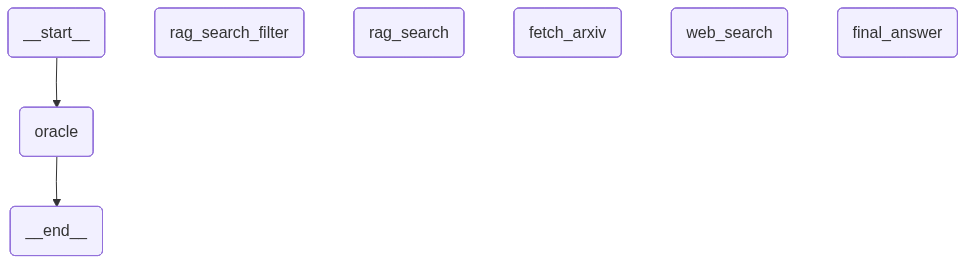

In [45]:
from IPython.display import Image, display

display(Image(runnable.get_graph().draw_mermaid_png()))

In [46]:
# Run the graph with input
output = runnable.invoke({
    'input': 'Tell me something interesting about Dynamic Backtracking AI and LLMs',
    'chat_history': []
})

run_oracle
intermediate_steps: []
web_search.invoke(input={'query': 'Dynamic backtracking algorithm constraint satisfaction and interactions with large language models (LLMs), applications and research'})
run_oracle
intermediate_steps: [AgentAction(tool='web_search', tool_input={'query': 'Dynamic backtracking algorithm constraint satisfaction and interactions with large language models (LLMs), applications and research'}, log='TBD'), AgentAction(tool='web_search', tool_input={'query': 'Dynamic backtracking algorithm constraint satisfaction and interactions with large language models (LLMs), applications and research'}, log="Water\nWater is an inorganic compound with the chemical formula H 2 O. It is a transparent, tasteless, odorless, [c] and nearly colorless chemical substance\nhttps://en.wikipedia.org/wiki/Water\n---\nWater | H2O | CID 962 - PubChem - NIH\nWater appears as a clear, nontoxic liquid composed of hydrogen and oxygen, essential for life and the most widely used solvent.\n

In [47]:
output['intermediate_steps'][-1].tool_input

{'introduction': 'Dynamic backtracking (a family of non-chronological backtracking methods for constraint satisfaction problems) and large language models (LLMs) sit in different historical and technical niches, but their intersection is rich and practically useful. Below I summarize the core idea of dynamic backtracking, then describe several concrete and surprising ways it can be combined with LLMs to make generation, program synthesis, constrained decoding, and repair more efficient and reliable.',
 'research_steps': '- Reviewed core concepts from the constraint-satisfaction and search literature (non-chronological backtracking, nogoods/conflict sets, backjumping). - Considered how constrained decoding, program synthesis, and neuro-symbolic systems currently use search and constraint solvers. - Mapped dynamic backtracking mechanics to token/variable choices in LLM generation and sketched practical integration patterns and limitations.',
 'main_body': '1) What dynamic backtracking is

### Building a Formatted Final Report

In [48]:
def build_report(output: dict) -> str:
    '''Builds a formatted report based on the oracle's output.

    Args:
        output (dict): A dictionary containing the various sections of the report (graph's output).

    Returns:
        str: A formatted string containing the full research report.
    '''
    research_steps = output['research_steps']
    if isinstance(research_steps, list):
        research_steps = '\n'.join([f'- {r}' for r in research_steps])
    
    sources = output['sources']
    if isinstance(sources, list):
        sources = '\n'.join([f'- {s}' for s in sources])
    
    return f"""
        INTRODUCTION
        ------------
        {output['introduction']}
        
        RESEARCH STEPS
        --------------
        {research_steps}
        
        REPORT
        ------
        {output['main_body']}
        
        CONCLUSION
        ----------
        {output['conclusion']}
        
        SOURCES
        -------
        {sources}
    """


In [49]:
# Run the graph with input.
output = runnable.invoke({
    'input': 'Tell me something interesting about Dynamic Backtracking AI and LLMs',
    'chat_history': [],
})

run_oracle
intermediate_steps: []
rag_search.invoke(input={'query': 'Dynamic backtracking algorithm constraint satisfaction and connections to large language models constrained decoding, neuro-symbolic integration, conflict-directed backtracking LLMs'})
run_oracle
intermediate_steps: [AgentAction(tool='rag_search', tool_input={'query': 'Dynamic backtracking algorithm constraint satisfaction and connections to large language models constrained decoding, neuro-symbolic integration, conflict-directed backtracking LLMs'}, log='TBD'), AgentAction(tool='rag_search', tool_input={'query': 'Dynamic backtracking algorithm constraint satisfaction and connections to large language models constrained decoding, neuro-symbolic integration, conflict-directed backtracking LLMs'}, log='Title: I like fish, especially dolphins: Addressing Contradictions in Dialogue Modeling\nChunk: Transformer NLI models, explicitly taking account\n1Our DECODE dataset is publicly available at https:\n//parl.ai/projects/co

In [50]:
output['intermediate_steps'][-1].tool_input

{'introduction': 'The user asked for something interesting about dynamic backtracking (from constraint-solving) and large language models (LLMs). Below is a short research-style response that explains what dynamic backtracking is, why it’s relevant to LLM decoding and reasoning, concrete ways the ideas map to generative models, practical benefits and limitations, and pointers for further reading.',
 'research_steps': '- Summarized classical CSP literature on dynamic backtracking and related non-chronological backtracking methods (conflict sets, nogoods, learning). - Mapped core ideas to decoding and constrained generation problems with LLMs (beam search, constrained decoding, neuro-symbolic loops). - Identified concrete algorithmic patterns (conflict sets per decision, targeted non-chronological revision, nogood learning) that could be applied to LLM outputs. - Assessed practical tradeoffs (computational cost, soft vs hard constraints) and suggested promising application areas and rese

In [51]:
report = build_report(
    output=output['intermediate_steps'][-1].tool_input
)

print(report)


        INTRODUCTION
        ------------
        The user asked for something interesting about dynamic backtracking (from constraint-solving) and large language models (LLMs). Below is a short research-style response that explains what dynamic backtracking is, why it’s relevant to LLM decoding and reasoning, concrete ways the ideas map to generative models, practical benefits and limitations, and pointers for further reading.

        RESEARCH STEPS
        --------------
        - Summarized classical CSP literature on dynamic backtracking and related non-chronological backtracking methods (conflict sets, nogoods, learning). - Mapped core ideas to decoding and constrained generation problems with LLMs (beam search, constrained decoding, neuro-symbolic loops). - Identified concrete algorithmic patterns (conflict sets per decision, targeted non-chronological revision, nogood learning) that could be applied to LLM outputs. - Assessed practical tradeoffs (computational cost, soft vs ha